In [20]:
import pandas as pd

# Hoja de Trabajo compilado para trabajar Napo en una sola.

In [21]:
SUM = pd.read_excel(r"Sumaco\iWUE_Sumaco.xlsx")
GAL = pd.read_excel(r"Galeras\iWUE_Galeras.xlsx")
SV = pd.read_excel(r"Selva Viva\iWUE_SV.xlsx")
OYC = pd.read_excel(r"Oyacachi_guacamayos\iWUE_OYC_GUA.xlsx")
#SF = pd.read_excel(r"SF_control\iWUE_SF.xlxs")
OYC.head(3)

,Unnamed: 0,new_TreeID,old_treeID,Plot,Site,family,species,leaf_sample_ID_2011,herbarium specimen,[C]%,...,Year,Type,Sample-ID,altitud,species (det 2008!),△13C_cell,Ci,Ci/Ca,iWUE (μmol/mol),Elevation
0,0,4039.0,4039.0,82.0,Oyacachi,Solanaceae,Solanum stenophyllum,56077.0,4194.0,45.059988,...,2011,leaf pulverized,NaN,NaN,NaN,16.793971,233.822968,0.603196,96.135645,4000.0
1,1,8016.0,4020.0,81.0,Oyacachi,Rosaceae,Polylepis pauta,56069.0,NaN,45.781855,...,2011,leaf pulverized,NaN,NaN,NaN,18.590224,264.632678,0.682676,76.879577,4000.0
2,2,8013.0,4021.0,81.0,Oyacachi,Asteraceae,Gynoxis acostae,56070.0,NaN,45.850566,...,2011,leaf pulverized,NaN,NaN,NaN,16.971226,236.863273,0.611039,94.235454,4000.0


In [22]:
###### GUACAMAYOS
OYC["species"] = OYC["species"].combine_first(OYC["species (det 2008!)"])

In [23]:
NAPO = pd.concat([SUM,GAL,SV,OYC])


In [24]:
### calcular nuevamente iWUE
import calculate_iWUE
%run calculate_iWUE

df = NAPO.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)
df.to_excel("NAPO.xlsx")
df.dtypes

Unnamed: 0                    int64
Sample-ID                    object
family                       object
genus                        object
species                      object
[C]%                        float64
δ13C (‰ v.s.V-PDB)          float64
Plot                         object
old_treeID                   object
Year                          int64
new_TreeID                  float64
△13C_cell                   float64
Ci                          float64
Ci/Ca                       float64
iWUE (μmol/mol)             float64
Site                         object
Elevation                   float64
PlotID                       object
[N]                         float64
[C_b]%                      float64
δ15N (‰ v.s. V-PDB)         float64
bulk_δ13C (‰ v.s.V-PDB)     float64
JH herbarium collections     object
Type                         object
leaf_sample_ID_2011         float64
herbarium specimen          float64
altitud                     float64
species (det 2008!)         

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


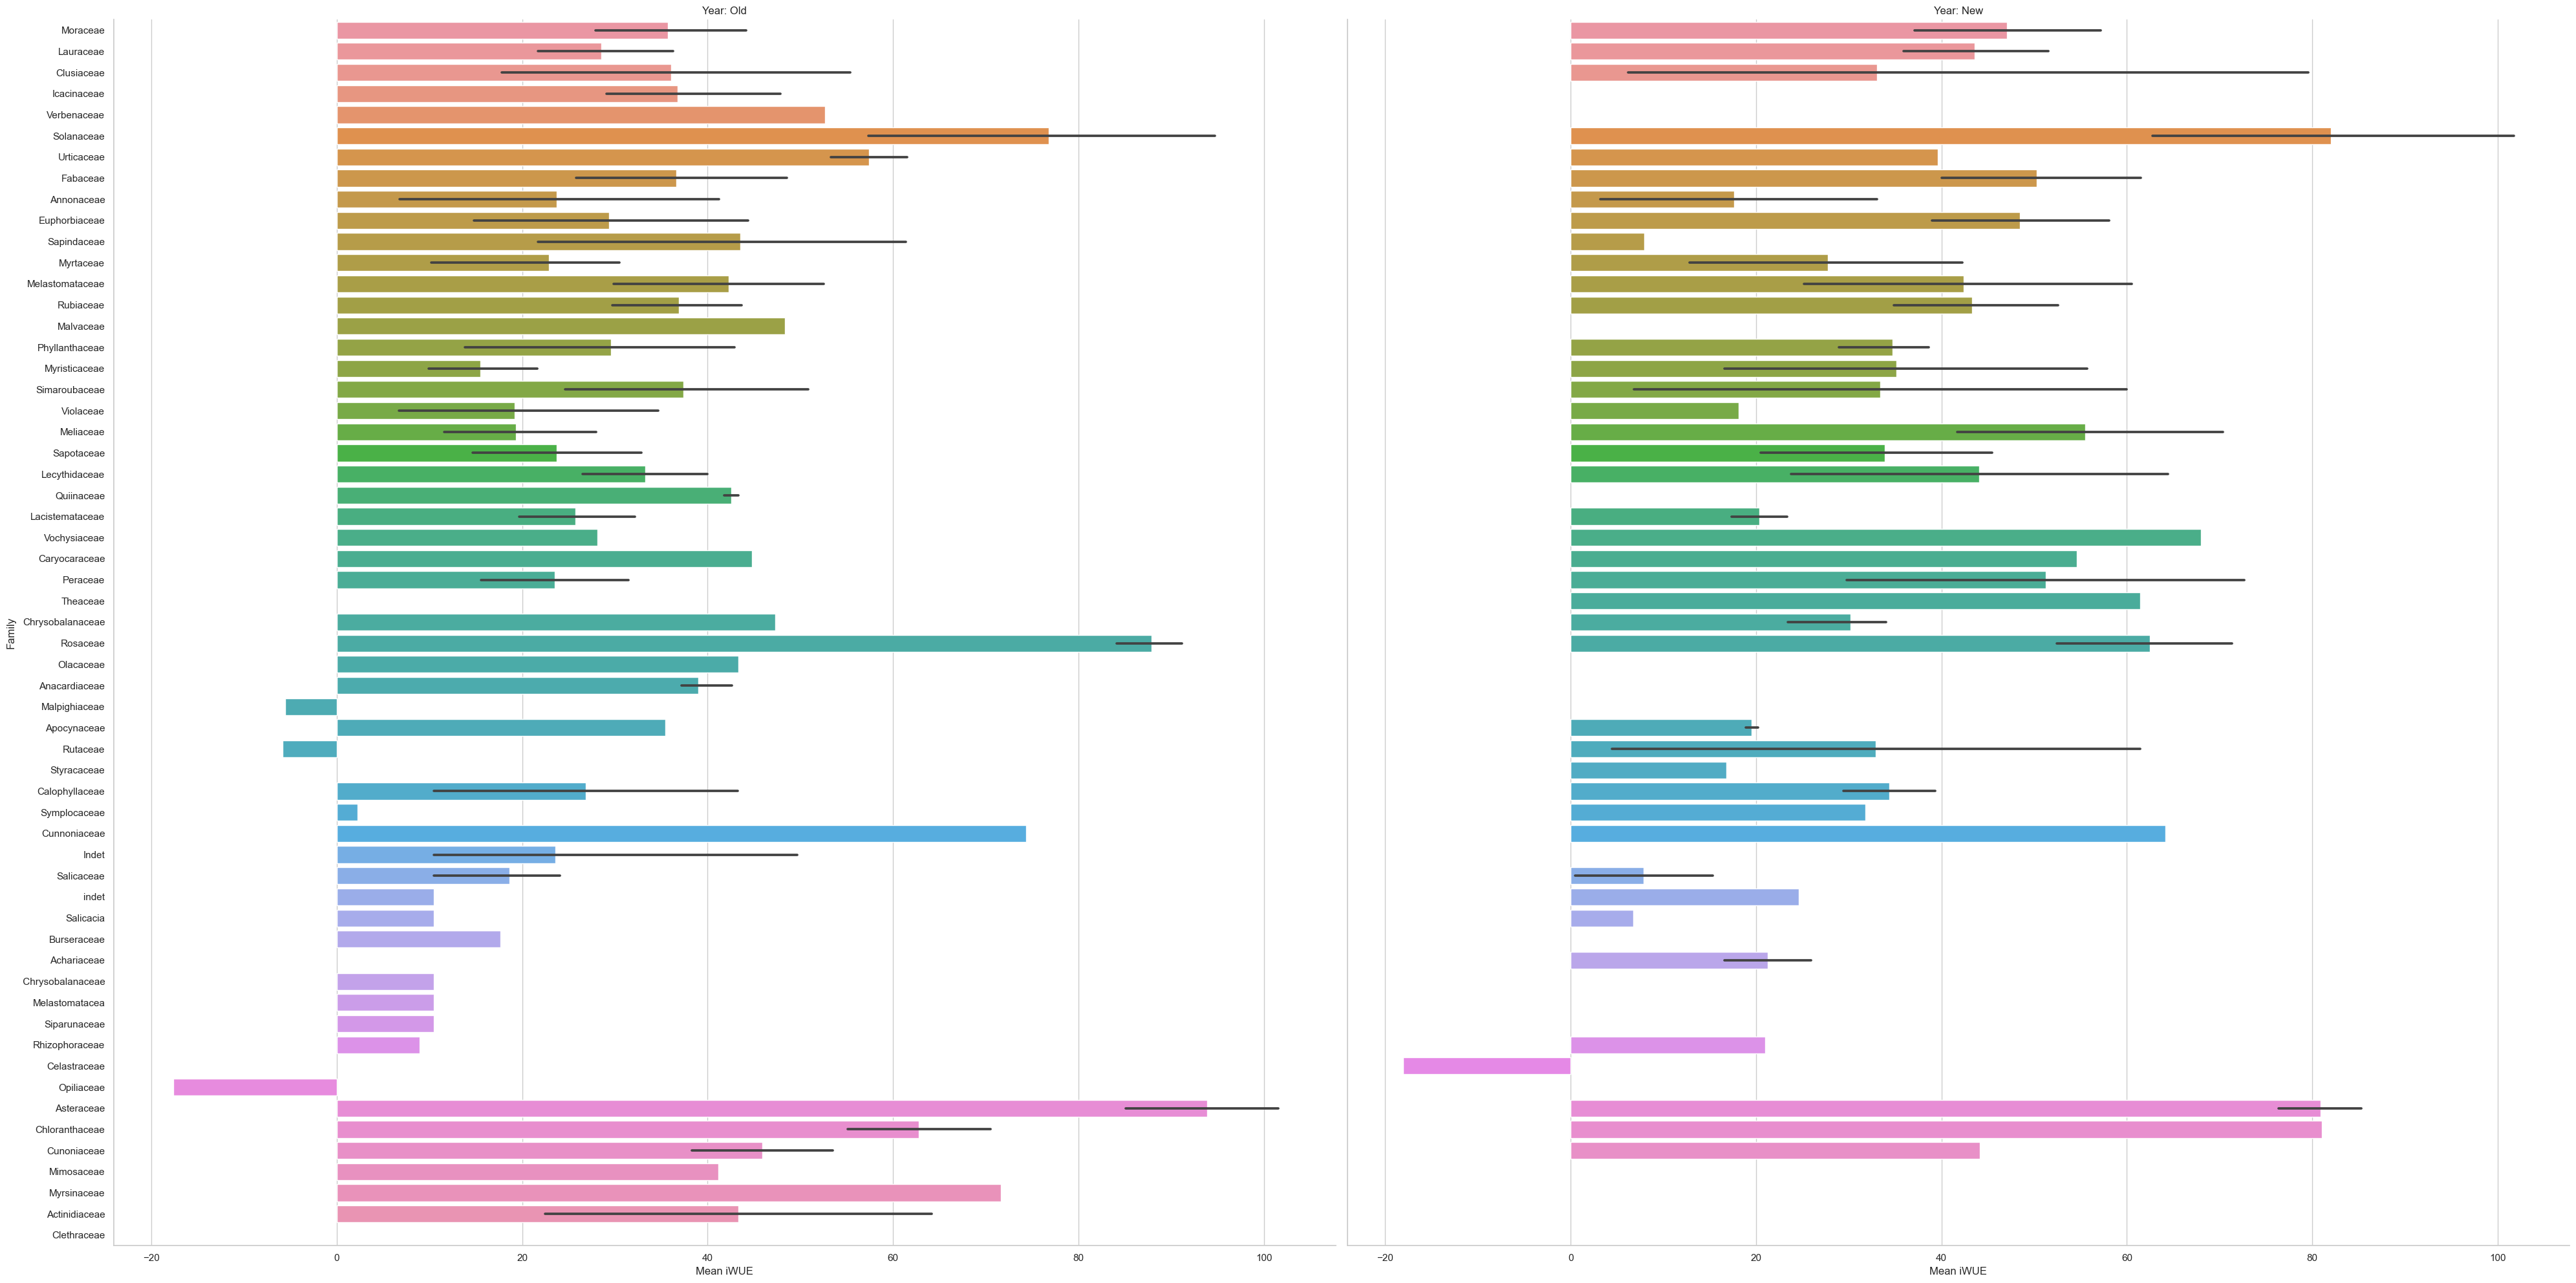

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Period"] = df["Year"].map({
    2005: "Old",
    2006: "Old",
    2007: "Old",
    2009: "Old",
    2011: "Old",
    2023: "New",
    2024: "New",
    2025: "New"
})
sns.set(style="whitegrid")

g = sns.catplot(
    data=df,
    x="iWUE (μmol/mol)",
    y="family",
    col="Period",
    kind="bar",
    height=20,
    aspect=1,
    sharex=True,
    sharey=True
)

g.set_axis_labels("Mean iWUE", "Family")
g.set_titles("Year: {col_name}")

plt.tight_layout()
plt.show()

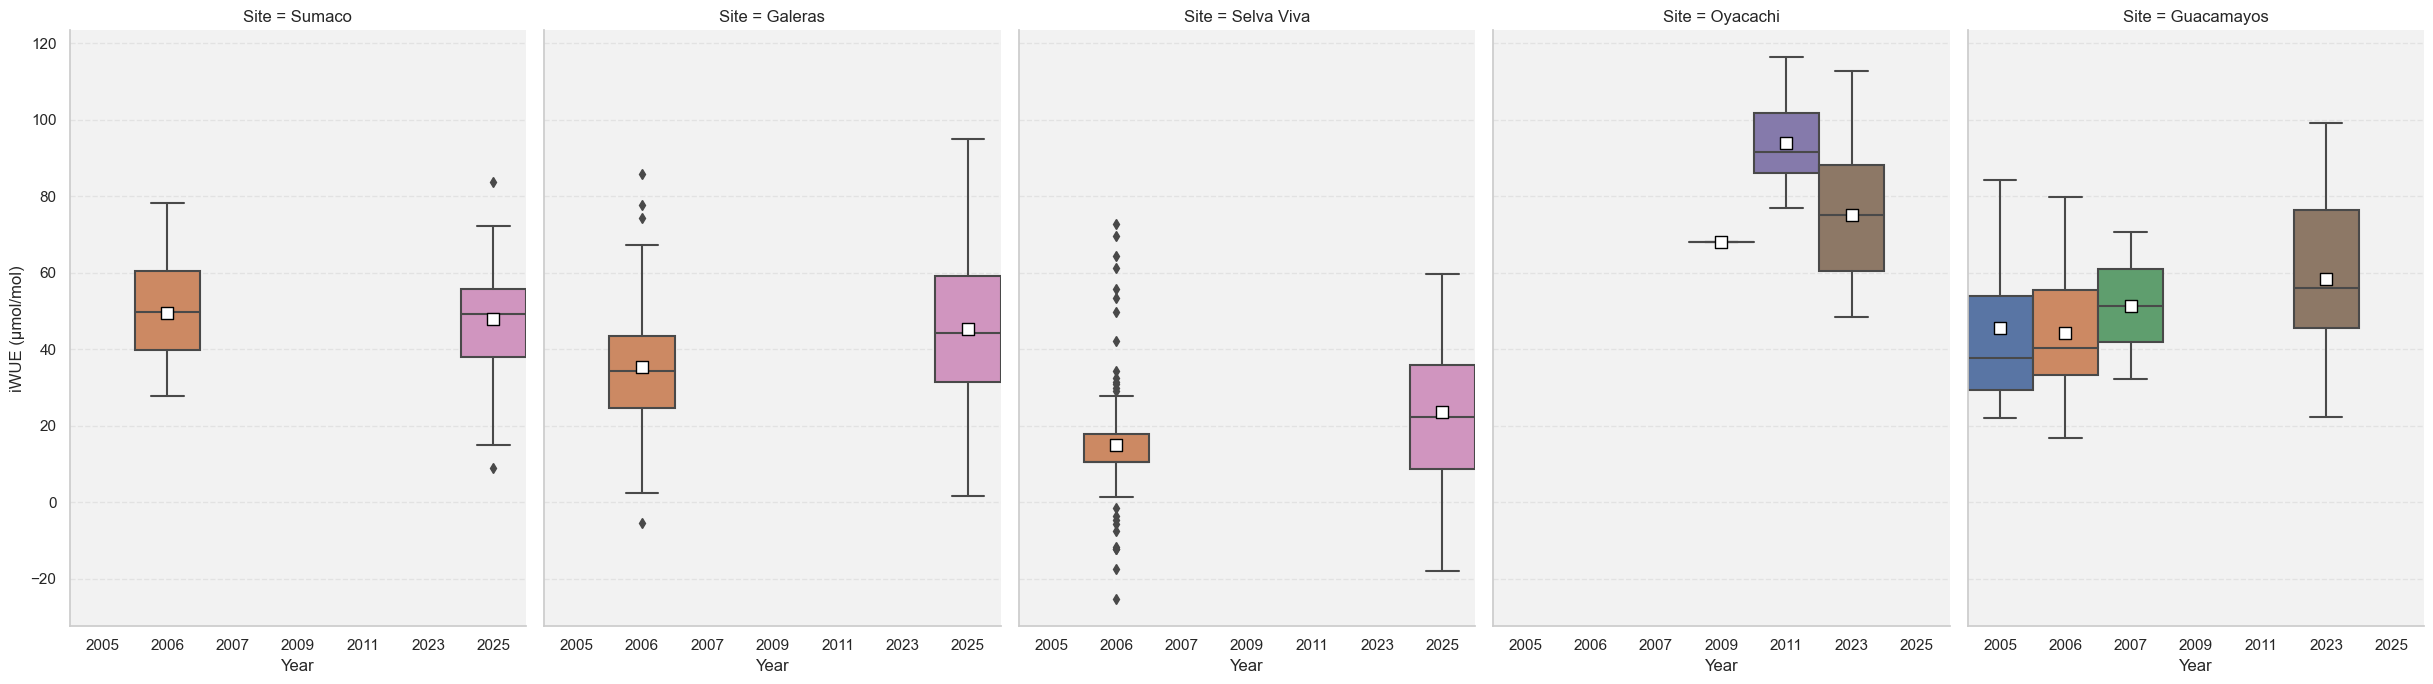

In [37]:

import seaborn as sns
import matplotlib.pyplot as plt


g = sns.catplot(
    data=df,
    x="Year",
    y="iWUE (μmol/mol)",
    col="Site",
    kind="box",
    height=7,          # menos alto pero más balanceado
    aspect=0.7,
    width=1       # opcional: quitar outliers (ruido visual)
)
for ax in g.axes.flat:
    ax.set_facecolor("#f2f2f2")   # gris más suave
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    
for ax in g.axes.flat:
    site = ax.get_title().split(" = ")[-1]

    subset = df[df["Site"] == site]

    years = sorted(df["Year"].unique())

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean().reindex(years)

    ax.scatter(
    range(len(years)),
    means,
    color="white",
    edgecolor="black",
    marker="s",
    s=80,
    zorder=5
    )

plt.tight_layout()
plt.show()

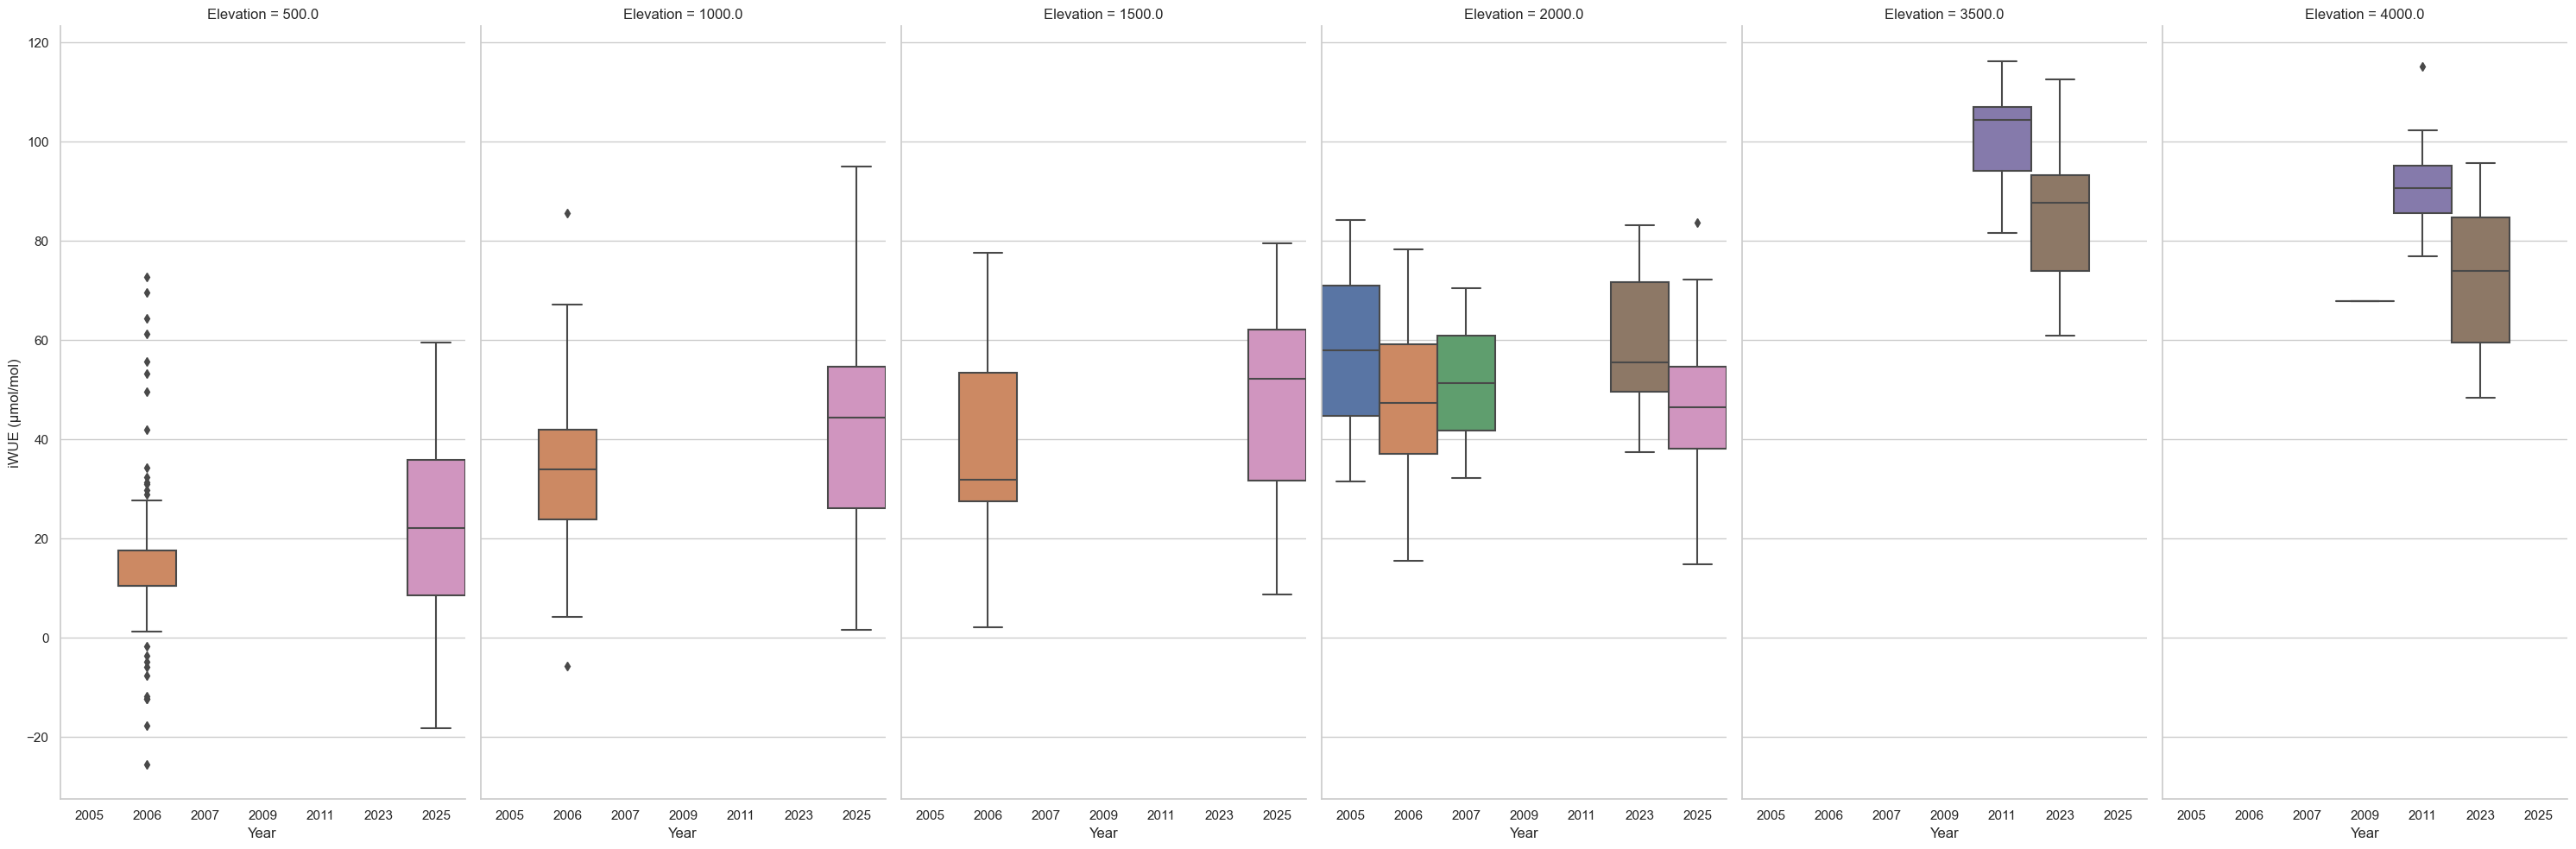

In [35]:

g = sns.catplot(
    data=df,
    x="Year",
    y="iWUE (μmol/mol)",
    col="Elevation",
    kind="box",
    height=10,          # menos alto pero más balanceado
    aspect=0.5,
    width=1      
)

plt.tight_layout()
plt.show()